**Kirjastojen tuonti ja asetukset**

Mitä tässä tehdään:

 Tuodaan kaikki tarvittavat Python-kirjastot ja lukitaan satunnaislukugeneraattoreiden siemenluvut (seeds). Valitaan myös automaattisesti laskentaan käytettävä laite (CPU tai GPU).Miksi tämä tehdään: Koneoppimiskokeiluissa tulosten toistettavuus on äärimmäisen tärkeää. Kun asetamme siemenluvut kiinteiksi (esim. SEED = 42), varmistamme, että mallin painoarvojen alustus ja datan sekoitus tapahtuvat aina samalla tavalla, jolloin koodin uudelleen ajaminen tuottaa samat tulokset. Laitteen valinta varmistaa koodin siirrettävyyden eri koneiden välillä.   

In [1]:
# --- Standard libraries ---
import os, time, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# --- Scikit-learn for metrics ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# --- Reproducibility ---
SEED = 42
random.seed(SEED)                  
np.random.seed(SEED)               
torch.manual_seed(SEED)            
torch.cuda.manual_seed_all(SEED)   

# --- Device selection ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Käytössä oleva laite: {device}")

Käytössä oleva laite: cpu


**Datan esikäsittely ja lataus**

Mitä tässä tehdään:
Määritellään kuvien muunnokset (koko, tensoriksi muuttaminen ja normalisointi). Ladataan kuvat opetus-, validointi- ja testikansioista (ImageFolder) ja luodaan niistä iteroidut eräkokokäsittelijät (DataLoader).

Miksi tämä tehdään: Esiopetetut mallit, kuten ResNet, on koulutettu ImageNet-datalla, ja ne vaativat, että syötekuvat skaalataan kokoon 224x224 ja normalisoidaan samoilla keskiarvoilla ja hajonnoilla kuin alkuperäinen opetusdata. Opetusdataan on lisätty pientä satunnaisuutta (Data Augmentation: kääntö ja rajaus), mikä auttaa mallia yleistämään oppimaansa paremmin. DataLoadereiden avulla data syötetään mallille pienissä erissä (batches) ja opetusdata sekoitetaan (shuffle), mikä on tärkeää stokastisen gradienttilaskun (SGD/Adam) toiminnalle.

In [2]:
data_dir = 'tree' 

# 1. Määritellään muunnokset (Transforms)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Ladataan datasetit
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

# 3. Luodaan DataLoaders
batch_size = 32
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Löydettiin {num_classes} luokkaa.")
print(f"Kuvia - Train: {len(image_datasets['train'])}, Val: {len(image_datasets['val'])}, Test: {len(image_datasets['test'])}")

Löydettiin 23 luokkaa.
Kuvia - Train: 3850, Val: 482, Test: 472


**Yleiskäyttöinen harjoitus- ja arviointifunktio (run_epoch)**

Mitä tässä tehdään:
Funktio käy koko annetun datasatsin läpi kerran (yksi epookki). Jos is_train=True, se päivittää mallin painoarvoja backpropagation-algoritmilla; muuten se toimii vain arviointitilassa.

Miksi tämä tehdään: Tämä pitää varsinaisen harjoitussilmukan siistinä ja kompaktina. Mallin asettaminen oikeaan tilaan (model.train() tai model.eval()) on kriittistä, sillä se vaikuttaa esimerkiksi Dropout- ja BatchNorm-kerrosten toimintaan. Funktio laskee ja palauttaa lopuksi moniluokitteluun soveltuvat arviointimittarit (esim. F1-score 'weighted'-asetuksella).

In [3]:
def run_epoch(model, dataloader, criterion, optimizer=None, is_train=True):
    """
    Yksi kokonainen läpikäynti dataloadrille (epookki).
    Opettajan Lab_05 run_epoch -funktion pohjalta muokattu moniluokitteluun.
    """
    # Asetetaan malli oikeaan tilaan (opetus vs. arviointi)
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        # Siirretään data samalle laitteelle kuin malli
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Nollataan gradientit opetusvaiheessa
        if is_train and optimizer is not None:
            optimizer.zero_grad()

        # Eteenpäin syöttö (Forward pass) ja häviön laskenta.
        # Lasketaan gradientit vain opetusvaiheessa.
        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Etsitään korkeimman todennäköisyyden saanut luokka (0-22)
            _, preds = torch.max(outputs, 1)

            # Taaksepäin levitys ja painojen päivitys opetusvaiheessa
            if is_train and optimizer is not None:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Koko epookin keskiarvotiedot
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    
    pr, rc, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    return epoch_loss, acc, pr, rc, f1, all_labels, all_preds

**Mallin alustus ja pääharjoitussilmukka**

Mitä tässä tehdään: 
Alustetaan ResNet18-malli siirto-oppimista varten korvaamalla sen alkuperäinen tulostekerros meidän 23 luokan kerroksella. Tämän jälkeen ajetaan toistuva silmukka, joka vuorotellen opettaa ja validoi mallia, ja tallentaa tulokset sanakirjaan (history).

Miksi tämä tehdään: Siirto-oppiminen on tehokas tapa hyödyntää muihin tehtäviin kehitettyjä monimutkaisia ominaisuuksien erottelijoita, mikä nopeuttaa ja parantaa oppimista. Harjoitussilmukka noudattaa opettajan esimerkin mukaista selkeää mallia, jossa koulutus- ja validointivaiheet on selkeästi erotettu ja tulokset tallennetaan vertailua varten.

In [7]:
# Ladataan esiopetettu ResNet18-malli
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Korvataan viimeinen kerros (fc) 23 puuluokkaan sopivaksi
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)
model_resnet18 = model_resnet18.to(device)

# Moniluokitteluun käytetään CrossEntropyLoss -funktiota
criterion = nn.CrossEntropyLoss()

# Optimoijaksi Adam
optimizer = optim.Adam(model_resnet18.parameters(), lr=0.001)

num_epochs = 1 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Aloitetaan mallin opetus...")

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    print("-" * 10)

    # 1. Opetusvaihe (päivittää painoarvoja)
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_resnet18, dataloaders['train'], criterion, optimizer, is_train=True
    )
    
    # 2. Validointivaihe (arvioi suorituskykyä näkemättömällä datalla)
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_resnet18, dataloaders['val'], criterion, is_train=False
    )

    # Tallennetaan historia kuvaajia varten (Opettajan esimerkin mukaisesti)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

print("Opetus valmis!")

Aloitetaan mallin opetus...
Epookki 1/1
----------
Train Loss: 2.2096 | Train Acc: 0.3538
Val Loss:   3.5178 | Val Acc:   0.3112 | Val F1: 0.2222

Opetus valmis!


In [ ]:
# Asetetaan 25 epookkia, jotta malli ehtii oppia kunnolla
import time


num_epochs = 25 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Aloitetaan mallin opetus (25 epookkia)...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    
    # 1. Opetusvaihe
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_resnet18, dataloaders['train'], criterion, optimizer, is_train=True
    )
    
    # 2. Validointivaihe
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_resnet18, dataloaders['val'], criterion, is_train=False
    )

    # Tallennetaan tulokset
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

total_time = time.time() - start_time
print(f"Opetus valmis! Aikaa kului: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Aloitetaan mallin opetus (25 epookkia)...
Epookki 1/1


KeyboardInterrupt: 

In [ ]:

import time
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# 1. Ladataan syvempi ResNet-50
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Muokataan viimeinen kerros meidän 23 puuluokkaan
num_ftrs_50 = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs_50, num_classes)
model_resnet50 = model_resnet50.to(device)

# 3. Määritetään uusi optimoija tälle mallille
optimizer_50 = optim.Adam(model_resnet50.parameters(), lr=0.001)

history_50 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
num_epochs = 25 

print("Aloitetaan ResNet-50 opetus (25 epookkia)...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    
    # Opetusvaihe uudella mallilla
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_resnet50, dataloaders['train'], criterion, optimizer_50, is_train=True
    )
    
    # Validointivaihe
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_resnet50, dataloaders['val'], criterion, is_train=False
    )

    history_50['train_loss'].append(train_loss)
    history_50['train_acc'].append(train_acc)
    history_50['val_loss'].append(val_loss)
    history_50['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

total_time = time.time() - start_time
print(f"Opetus valmis! Aikaa kului: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Frans/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Aloitetaan ResNet-50 opetus (25 epookkia)...
Epookki 1/1
Train Loss: 1.8280 | Train Acc: 0.4792
Val Loss:   1.5394 | Val Acc:   0.5477 | Val F1: 0.5520

Opetus valmis! Aikaa kului: 3m 52s


In [ ]:
import time
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# 1. Ladataan esiopetettu EfficientNet-B0 (kevyt, mutta tehokas perusmalli)
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Muokataan viimeinen kerros 23 puuluokkaan. 
# Huom! EfficientNetissä luokittelukerros on nimeltään 'classifier', eikä 'fc' kuten ResNetissä.
num_ftrs_eff = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)
model_effnet = model_effnet.to(device)

# 3. Määritetään optimoija
optimizer_eff = optim.Adam(model_effnet.parameters(), lr=0.001)

history_eff = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
num_epochs = 25 

print("Aloitetaan EfficientNet-B0 opetus (25 epookkia)...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    
    # Opetusvaihe (huomaa model_effnet ja optimizer_eff)
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_effnet, dataloaders['train'], criterion, optimizer_eff, is_train=True
    )
    
    # Validointivaihe
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_effnet, dataloaders['val'], criterion, is_train=False
    )

    history_eff['train_loss'].append(train_loss)
    history_eff['train_acc'].append(train_acc)
    history_eff['val_loss'].append(val_loss)
    history_eff['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

total_time = time.time() - start_time
print(f"Opetus valmis! Aikaa kului: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Aloitetaan EfficientNet-B0 opetus (25 epookkia)...
Epookki 1/25


NameError: name 'criterion' is not defined

**Oppimiskäyrien visualisointi**

Mitä tässä tehdään: 
Piirretään matplotlib-kirjastolla kaksi kuvaajaa. Toinen näyttää häviön (loss) ja toinen tarkkuuden (accuracy) kehityksen opetus- ja validointidatalla.
Miksi tämä tehdään: Visuaaliset käyrät ovat paras tapa havaita, oppiiko malli oikein vai alkaako se ylisovittua (overfit). Jos validointihäviö alkaa nousta, vaikka opetushäviö jatkaa laskuaan, malli ylisovittuu.

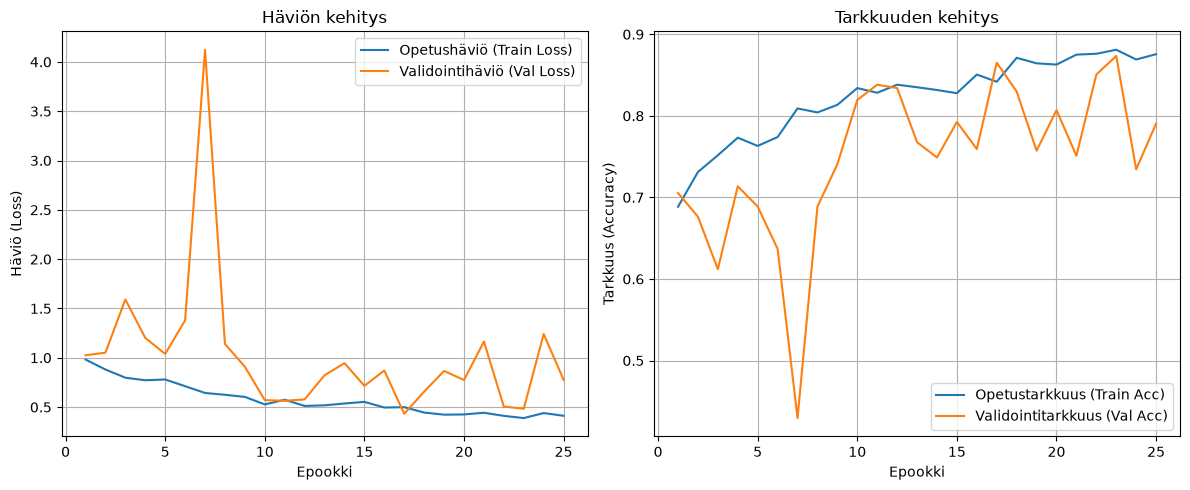

In [10]:
# Piirretään häviö- ja tarkkuuskäyrät
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Häviö (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Opetushäviö (Train Loss)')
plt.plot(epochs_range, history['val_loss'], label='Validointihäviö (Val Loss)')
plt.title('Häviön kehitys')
plt.xlabel('Epookki')
plt.ylabel('Häviö (Loss)')
plt.legend()
plt.grid(True)

# Tarkkuus (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Opetustarkkuus (Train Acc)')
plt.plot(epochs_range, history['val_acc'], label='Validointitarkkuus (Val Acc)')
plt.title('Tarkkuuden kehitys')
plt.xlabel('Epookki')
plt.ylabel('Tarkkuus (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Lopullinen testaus, sekaannusmatriisi ja n-best -tarkkuus**

Mitä tässä tehdään:
 Projektiohjeen mukaisesti arvioimme mallin suorituskykyä täysin ennennäkemättömällä testidatalla (test_loader). Laskemme tarkkuuden, F1-pisteet, piirrämme sekaannusmatriisin (Confusion Matrix) ja teemme n-best -arvioinnin (esim. top-1, top-3, top-5).
Miksi tämä tehdään:
 Testidata kertoo mallin todellisen suorituskyvyn tuotannossa. Sekaannusmatriisi on kriittinen, jotta voitte raportissanne analysoida, "tekeekö malli virheitä, jotka toistavat itseään" (kuten tehtävänanto vaatii). Top-N -mittarit paljastavat, oliko oikea puulaji mallin mielestä lähellä (vaikka paras arvaus olisikin ollut väärin).

Arvioidaan mallia Testi-datalla...
Testitulokset: Tarkkuus (Acc): 0.8157 | Täsmällisyys (Precision): 0.8429 | Saanti (Recall): 0.8157 | F1: 0.8102


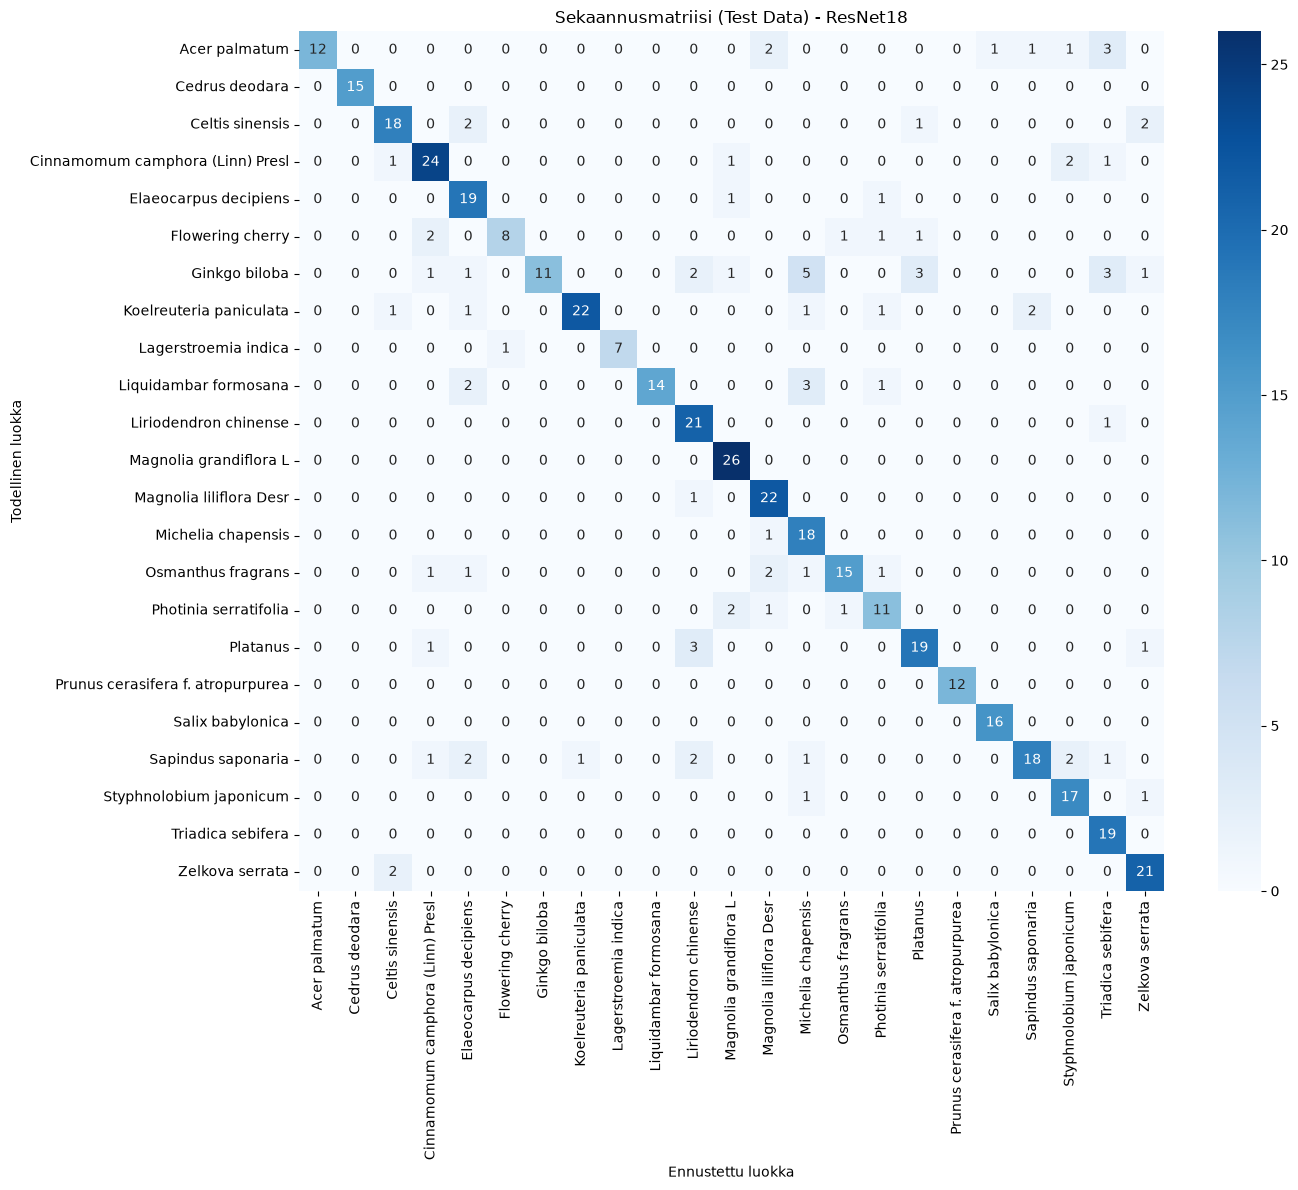


N-best luokittelutulokset (Test Data):
Top-1 Tarkkuus: 0.8157
Top-2 Tarkkuus: 0.9004
Top-3 Tarkkuus: 0.9237
Top-5 Tarkkuus: 0.9597


In [11]:
print("Arvioidaan mallia Testi-datalla...")
# 1. Perusmittarit testidatalle
test_loss, test_acc, test_pr, test_rc, test_f1, test_labels, test_preds = run_epoch(
    model_resnet18, dataloaders['test'], criterion, is_train=False
)

print(f"Testitulokset: Tarkkuus (Acc): {test_acc:.4f} | Täsmällisyys (Precision): {test_pr:.4f} | Saanti (Recall): {test_rc:.4f} | F1: {test_f1:.4f}")

# 2. Sekaannusmatriisi (Confusion Matrix)
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Sekaannusmatriisi (Test Data) - ResNet18')
plt.xlabel('Ennustettu luokka')
plt.ylabel('Todellinen luokka')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Top-N tarkkuuden laskenta (Tehtävänannon "n-best" vaatimus)
def evaluate_top_n(model, dataloader, top_n_list=[1, 3, 5]):
    model.eval()
    correct_counts = {n: 0 for n in top_n_list}
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            total += labels.size(0)
            
            # Etsitään n suurinta todennäköisyyttä
            max_n = max(top_n_list)
            _, top_preds = outputs.topk(max_n, dim=1, largest=True, sorted=True)
            
            for n in top_n_list:
                # Katsotaan onko oikea vastaus top-N joukossa
                correct = top_preds[:, :n].eq(labels.view(-1, 1).expand_as(top_preds[:, :n]))
                correct_counts[n] += correct.sum().item()
                
    for n in top_n_list:
        acc = correct_counts[n] / total
        print(f"Top-{n} Tarkkuus: {acc:.4f}")

print("\nN-best luokittelutulokset (Test Data):")
evaluate_top_n(model_resnet18, dataloaders['test'], top_n_list=[1, 2, 3, 5])

In [12]:
import torch

def evaluate_top_n(model, dataloader, top_n_list=[1, 3, 5]):
    # Asetetaan malli arviointitilaan
    model.eval()
    correct_counts = {n: 0 for n in top_n_list}
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Mallin raa'at ennusteet
            outputs = model(inputs)
            total += labels.size(0)
            
            # Etsitään suurin tarvittava määrä (N) parhaita arvauksia
            max_n = max(top_n_list)
            _, top_preds = outputs.topk(max_n, dim=1, largest=True, sorted=True)
            
            for n in top_n_list:
                # Verrataan, onko todellinen luokka (label) top-N ennusteiden joukossa
                correct = top_preds[:, :n].eq(labels.view(-1, 1).expand_as(top_preds[:, :n]))
                correct_counts[n] += correct.sum().item()
                
    print("\n=== OMAN MALLIN TOP-N TULOKSET ===")
    for n in top_n_list:
        acc = correct_counts[n] / total
        print(f"Top-{n} Tarkkuus: {acc:.4f}")

# Kutsutaan funktiota omalle mallille ja testidatalle
# Huom: Vaihda ensimmäiseksi parametriksi se malli, jota juuri koulutat (esim. model_resnet50)
evaluate_top_n(model_resnet18, dataloaders['test'], top_n_list=[1, 3, 5])


=== OMAN MALLIN TOP-N TULOKSET ===
Top-1 Tarkkuus: 0.8157
Top-3 Tarkkuus: 0.9237
Top-5 Tarkkuus: 0.9597


In [10]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Moniluokitteluun käytettävä häviöfunktio
criterion = nn.CrossEntropyLoss()

# --- 1. RESNET-50 ALUSTUS ---
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs_50 = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs_50, num_classes)
model_resnet50 = model_resnet50.to(device)
optimizer_50 = optim.Adam(model_resnet50.parameters(), lr=0.001)

# --- 2. EFFICIENTNET-B0 ALUSTUS ---
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs_eff = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)
model_effnet = model_effnet.to(device)
optimizer_eff = optim.Adam(model_effnet.parameters(), lr=0.001)

print("Mallit ja optimoijat alustettu onnistuneesti!")

Mallit ja optimoijat alustettu onnistuneesti!


Aloitetaan ResNet-50 opetus (25 epookkia)...
Epookki 1/25 - Val Acc: 0.6390 | Val F1: 0.6143
Epookki 2/25 - Val Acc: 0.6411 | Val F1: 0.6532
Epookki 3/25 - Val Acc: 0.7033 | Val F1: 0.6787
Epookki 4/25 - Val Acc: 0.6639 | Val F1: 0.6403
Epookki 5/25 - Val Acc: 0.6680 | Val F1: 0.6603
Epookki 6/25 - Val Acc: 0.7884 | Val F1: 0.7847
Epookki 7/25 - Val Acc: 0.8610 | Val F1: 0.8595
Epookki 8/25 - Val Acc: 0.7593 | Val F1: 0.7613
Epookki 9/25 - Val Acc: 0.8734 | Val F1: 0.8741
Epookki 10/25 - Val Acc: 0.7490 | Val F1: 0.7407
Epookki 11/25 - Val Acc: 0.8921 | Val F1: 0.8925
Epookki 12/25 - Val Acc: 0.7801 | Val F1: 0.7592
Epookki 13/25 - Val Acc: 0.8817 | Val F1: 0.8773
Epookki 14/25 - Val Acc: 0.8797 | Val F1: 0.8776
Epookki 15/25 - Val Acc: 0.8133 | Val F1: 0.8147
Epookki 16/25 - Val Acc: 0.9046 | Val F1: 0.9043
Epookki 17/25 - Val Acc: 0.8589 | Val F1: 0.8586
Epookki 18/25 - Val Acc: 0.9108 | Val F1: 0.9096
Epookki 19/25 - Val Acc: 0.9108 | Val F1: 0.9093
Epookki 20/25 - Val Acc: 0.9295 |

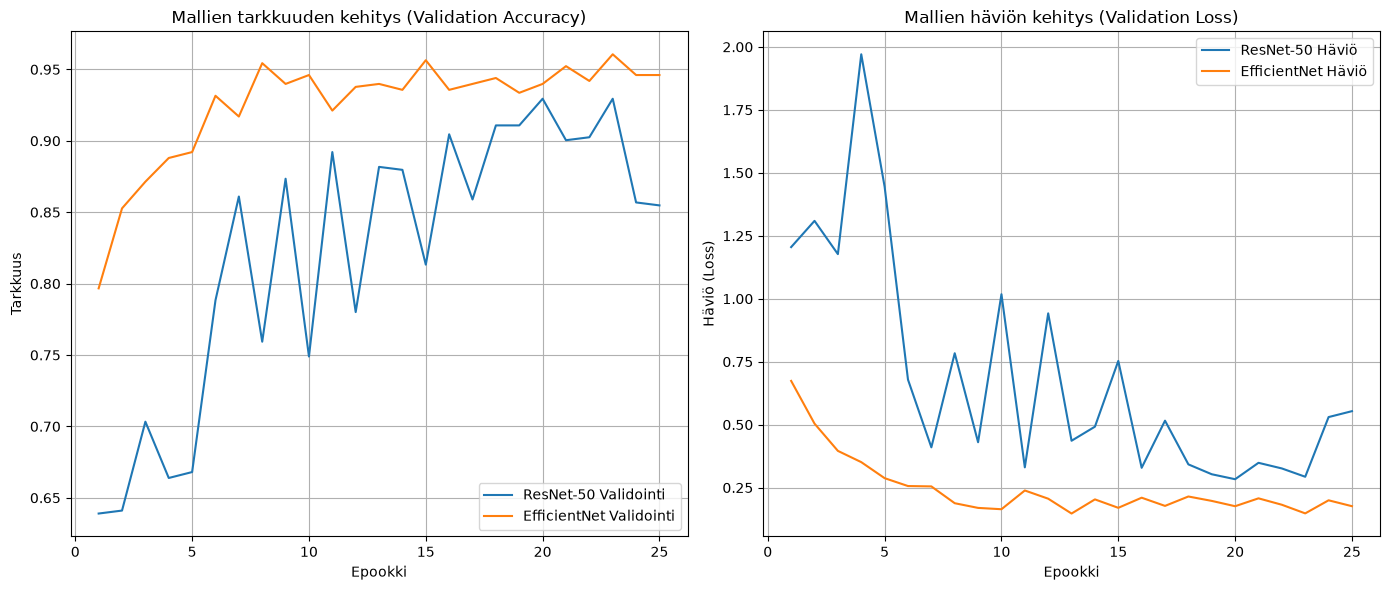

\nArvioidaan mallia ResNet50 Testi-datalla...
Tarkkuus: 0.8347 | F1: 0.8286


NameError: name 'evaluate_top_n' is not defined

In [11]:
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

num_epochs = 25

# --- 1. RESNET-50 OPETUS ---
print("Aloitetaan ResNet-50 opetus (25 epookkia)...")
history_50 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc, _, _, _, _, _ = run_epoch(model_resnet50, dataloaders['train'], criterion, optimizer_50, is_train=True)
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(model_resnet50, dataloaders['val'], criterion, is_train=False)
    
    history_50['train_loss'].append(train_loss)
    history_50['train_acc'].append(train_acc)
    history_50['val_loss'].append(val_loss)
    history_50['val_acc'].append(val_acc)
    print(f"Epookki {epoch+1}/{num_epochs} - Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

print(f"ResNet-50 opetus valmis! Aikaa kului: {(time.time() - start_time) // 60:.0f} min\n")


# --- 2. EFFICIENTNET-B0 OPETUS ---
print("Aloitetaan EfficientNet-B0 opetus (25 epookkia)...")
history_eff = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc, _, _, _, _, _ = run_epoch(model_effnet, dataloaders['train'], criterion, optimizer_eff, is_train=True)
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(model_effnet, dataloaders['val'], criterion, is_train=False)
    
    history_eff['train_loss'].append(train_loss)
    history_eff['train_acc'].append(train_acc)
    history_eff['val_loss'].append(val_loss)
    history_eff['val_acc'].append(val_acc)
    print(f"Epookki {epoch+1}/{num_epochs} - Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

print(f"EfficientNet opetus valmis! Aikaa kului: {(time.time() - start_time) // 60:.0f} min\n")


# --- 3. OPPIMISKÄYRIEN VERTAILU ---
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_50['val_acc'], label='ResNet-50 Validointi')
plt.plot(epochs_range, history_eff['val_acc'], label='EfficientNet Validointi')
plt.title('Mallien tarkkuuden kehitys (Validation Accuracy)')
plt.xlabel('Epookki')
plt.ylabel('Tarkkuus')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_50['val_loss'], label='ResNet-50 Häviö')
plt.plot(epochs_range, history_eff['val_loss'], label='EfficientNet Häviö')
plt.title('Mallien häviön kehitys (Validation Loss)')
plt.xlabel('Epookki')
plt.ylabel('Häviö (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('oppimiskayrat_vertailu.png', bbox_inches='tight')
plt.show()


# --- 4. TESTAUS JA SEKAANNUSMATRIISIT ---
def plot_and_evaluate(model, model_name):
    print(f"\\nArvioidaan mallia {model_name} Testi-datalla...")
    _, test_acc, _, _, test_f1, test_labels, test_preds = run_epoch(model, dataloaders['test'], criterion, is_train=False)
    print(f"Tarkkuus: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # N-best
    evaluate_top_n(model, dataloaders['test'], top_n_list=[1, 2, 3, 5])
    
    # Sekaannusmatriisin tallennus
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Sekaannusmatriisi - {model_name}')
    plt.xlabel('Ennustettu luokka')
    plt.ylabel('Todellinen luokka')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'sekaannusmatriisi_{model_name.lower()}.png', bbox_inches='tight')
    plt.close() # Sulkee kuvan muistista, jotta seuraava voi piirtyä

plot_and_evaluate(model_resnet50, "ResNet50")
plot_and_evaluate(model_effnet, "EfficientNet")

In [12]:
import torch

# 1. Määritellään puuttuva Top-N -funktio uudelleen tähän istuntoon
def evaluate_top_n(model, dataloader, top_n_list=[1, 3, 5]):
    model.eval()
    correct_counts = {n: 0 for n in top_n_list}
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            total += labels.size(0)
            
            max_n = max(top_n_list)
            _, top_preds = outputs.topk(max_n, dim=1, largest=True, sorted=True)
            
            for n in top_n_list:
                correct = top_preds[:, :n].eq(labels.view(-1, 1).expand_as(top_preds[:, :n]))
                correct_counts[n] += correct.sum().item()
                
    print("--- TOP-N TULOKSET ---")
    for n in top_n_list:
        acc = correct_counts[n] / total
        print(f"Top-{n} Tarkkuus: {acc:.4f}")

# 2. Ajetaan lopullinen testaus aiemmin muistiin jääneille malleille
plot_and_evaluate(model_resnet50, "ResNet50")
plot_and_evaluate(model_effnet, "EfficientNet")

\nArvioidaan mallia ResNet50 Testi-datalla...
Tarkkuus: 0.8347 | F1: 0.8286
--- TOP-N TULOKSET ---
Top-1 Tarkkuus: 0.8347
Top-2 Tarkkuus: 0.9089
Top-3 Tarkkuus: 0.9364
Top-5 Tarkkuus: 0.9640
\nArvioidaan mallia EfficientNet Testi-datalla...
Tarkkuus: 0.8962 | F1: 0.8956
--- TOP-N TULOKSET ---
Top-1 Tarkkuus: 0.8962
Top-2 Tarkkuus: 0.9386
Top-3 Tarkkuus: 0.9597
Top-5 Tarkkuus: 0.9746


In [16]:
def plot_and_evaluate(model, model_name):
    print(f"\\nArvioidaan mallia {model_name} Testi-datalla...")
    _, test_acc, _, _, test_f1, test_labels, test_preds = run_epoch(model, dataloaders['test'], criterion, is_train=False)
    print(f"Tarkkuus: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # N-best
    evaluate_top_n(model, dataloaders['test'], top_n_list=[1, 2, 3, 5])
    
    # Sekaannusmatriisin tallennus
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Sekaannusmatriisi - {model_name}')
    plt.xlabel('Ennustettu luokka')
    plt.ylabel('Todellinen luokka')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'sekaannusmatriisi_{model_name.lower()}.png', bbox_inches='tight')
    plt.close() # Sulkee kuvan muistista, jotta seuraava voi piirtyä

plot_and_evaluate(model_resnet50, "ResNet50")
plot_and_evaluate(model_effnet, "EfficientNet")


\nArvioidaan mallia ResNet50 Testi-datalla...
Tarkkuus: 0.8347 | F1: 0.8286
--- TOP-N TULOKSET ---
Top-1 Tarkkuus: 0.8347
Top-2 Tarkkuus: 0.9089
Top-3 Tarkkuus: 0.9364
Top-5 Tarkkuus: 0.9640
\nArvioidaan mallia EfficientNet Testi-datalla...
Tarkkuus: 0.8962 | F1: 0.8956
--- TOP-N TULOKSET ---
Top-1 Tarkkuus: 0.8962
Top-2 Tarkkuus: 0.9386
Top-3 Tarkkuus: 0.9597
Top-5 Tarkkuus: 0.9746


In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Määritellään testausfunktio, joka osaa myös piirtää matriisin
def evaluate_and_plot(model, model_name, dataloader_test, top_n_list=[1, 2, 3, 5]):
    print(f"\n================ Arvioidaan {model_name} ================")
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in dataloader_test:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            # Lasketaan todennäköisyydet Top-N varten
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.vstack(all_probs)
    
    # Perusmetriikat
    print("--- CLASSIFICATION REPORT ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # Top-N tarkkuudet
    print("\n--- TOP-N TULOKSET ---")
    for k in top_n_list:
        topk_preds = np.argsort(all_probs, axis=1)[:, -k:]
        correct = sum([all_labels[i] in topk_preds[i] for i in range(len(all_labels))])
        topk_acc = correct / len(all_labels)
        print(f'Top-{k} Tarkkuus: {topk_acc:.4f}')
        
    # Sekaannusmatriisin tallennus
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Sekaannusmatriisi - {model_name}')
    plt.xlabel('Ennustettu luokka')
    plt.ylabel('Todellinen luokka')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'sekaannusmatriisi_{model_name.lower()}.png', bbox_inches='tight')
    plt.close() # Sulkee kuvan, jottei se jää tukkimaan muistia
    print(f"Sekaannusmatriisi tallennettu: sekaannusmatriisi_{model_name.lower()}.png")

# 2. Kutsutaan funktiota muistissa oleville malleille
evaluate_and_plot(model_resnet50, "ResNet50", dataloaders['test'])
evaluate_and_plot(model_effnet, "EfficientNet", dataloaders['test'])


================ Arvioidaan ResNet50 ================
--- CLASSIFICATION REPORT ---
                                   precision    recall  f1-score   support

                    Acer palmatum     0.8947    0.8500    0.8718        20
                   Cedrus deodara     1.0000    1.0000    1.0000        15
                  Celtis sinensis     1.0000    0.3043    0.4667        23
 Cinnamomum camphora (Linn) Presl     0.9583    0.7931    0.8679        29
            Elaeocarpus decipiens     0.8750    1.0000    0.9333        21
                 Flowering cherry     0.7333    0.8462    0.7857        13
                    Ginkgo biloba     0.8696    0.7143    0.7843        28
          Koelreuteria paniculata     0.7576    0.8929    0.8197        28
             Lagerstroemia indica     1.0000    0.8750    0.9333         8
            Liquidambar formosana     1.0000    0.7500    0.8571        20
            Liriodendron chinense     1.0000    0.6364    0.7778        22
           Mag